## Preliminares

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.config import data_folder
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4540 non-null   datetime64[ns]
 1   Open                    4540 non-null   float64       
 2   Close                   4540 non-null   float64       
 3   Dividends               4540 non-null   float64       
 4   Ticker                  4540 non-null   object        
 5   Sector                  4540 non-null   object        
 6   DateAdded               4540 non-null   object        
 7   TotalRevenue            4540 non-null   float64       
 8   GrossProfit             4324 non-null   float64       
 9   OperatingIncome         4540 non-null   float64       
 10  NetIncome               4540 non-null   float64       
 11  EBITDA                  4540 non-null   float64       
 12  BasicAverageShares      4538 non-null   float64 

In [3]:
# Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres)
df = transformar_flujos_a_ttm(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4540 non-null   datetime64[ns]
 1   Open                    4540 non-null   float64       
 2   Close                   4540 non-null   float64       
 3   Dividends               4540 non-null   float64       
 4   Ticker                  4540 non-null   object        
 5   Sector                  4540 non-null   object        
 6   DateAdded               4540 non-null   object        
 7   CashAndCashEquivalents  4535 non-null   float64       
 8   CurrentDebt             3847 non-null   float64       
 9   LongTermDebt            4372 non-null   float64       
 10  TotalDebt               4054 non-null   float64       
 11  StockholdersEquity      4536 non-null   float64       
 12  TotalAssets             4536 non-null   float64 

In [4]:
# Valores missing
df.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.287004
CapitalExpenditure_TTM    0.242070
FreeCashFlow_TTM          0.240088
OperatingCashFlow_TTM     0.235463
InvestingCashFlow_TTM     0.235463
FinancingCashFlow_TTM     0.235463
BasicAverageShares_TTM    0.235022
TotalRevenue_TTM          0.234581
OperatingIncome_TTM       0.234581
NetIncome_TTM             0.234581
EBITDA_TTM                0.234581
CurrentDebt               0.152643
TotalDebt                 0.107048
LongTermDebt              0.037004
CashAndCashEquivalents    0.001101
CurrentLiabilities        0.000881
TotalAssets               0.000881
StockholdersEquity        0.000881
CurrentAssets             0.000881
DateAdded                 0.000000
Ticker                    0.000000
Dividends                 0.000000
Close                     0.000000
Open                      0.000000
Date                      0.000000
Sector                    0.000000
dtype: float64

In [5]:
# Se imputan parte de los NaNs en variables de Deuda antes de calcular métricas, 
# mediante las relaciones contables entre ellas.
df_debt_imputed = imputar_deuda(df)
df_debt_imputed.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.287004
CapitalExpenditure_TTM    0.242070
FreeCashFlow_TTM          0.240088
OperatingCashFlow_TTM     0.235463
InvestingCashFlow_TTM     0.235463
FinancingCashFlow_TTM     0.235463
BasicAverageShares_TTM    0.235022
TotalRevenue_TTM          0.234581
OperatingIncome_TTM       0.234581
NetIncome_TTM             0.234581
EBITDA_TTM                0.234581
CurrentDebt               0.115419
TotalDebt                 0.107048
LongTermDebt              0.034802
CashAndCashEquivalents    0.001101
CurrentLiabilities        0.000881
TotalAssets               0.000881
StockholdersEquity        0.000881
CurrentAssets             0.000881
DateAdded                 0.000000
Ticker                    0.000000
Dividends                 0.000000
Close                     0.000000
Open                      0.000000
Date                      0.000000
Sector                    0.000000
dtype: float64

In [6]:
# Calcular métricas
df_with_metrics, crecimiento_cols = calcular_metricas(df_debt_imputed)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4540 non-null   datetime64[ns]
 1   Open                    4540 non-null   float64       
 2   Close                   4540 non-null   float64       
 3   Dividends               4540 non-null   float64       
 4   Ticker                  4540 non-null   object        
 5   Sector                  4540 non-null   object        
 6   DateAdded               4540 non-null   object        
 7   CashAndCashEquivalents  4535 non-null   float64       
 8   CurrentDebt             4016 non-null   float64       
 9   LongTermDebt            4382 non-null   float64       
 10  TotalDebt               4054 non-null   float64       
 11  StockholdersEquity      4536 non-null   float64       
 12  TotalAssets             4536 non-null   float64 

In [7]:
# Se aplica imputación transversal para las columnas de crecimiento
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4540 non-null   datetime64[ns]
 1   Open                    4540 non-null   float64       
 2   Close                   4540 non-null   float64       
 3   Dividends               4540 non-null   float64       
 4   Ticker                  4540 non-null   object        
 5   Sector                  4540 non-null   object        
 6   DateAdded               4540 non-null   object        
 7   CashAndCashEquivalents  4535 non-null   float64       
 8   CurrentDebt             4016 non-null   float64       
 9   LongTermDebt            4382 non-null   float64       
 10  TotalDebt               4054 non-null   float64       
 11  StockholdersEquity      4536 non-null   float64       
 12  TotalAssets             4536 non-null   float64 

In [8]:
# Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    4540 non-null   datetime64[ns]
 1   Open                    4540 non-null   float64       
 2   Close                   4540 non-null   float64       
 3   Dividends               4540 non-null   float64       
 4   Ticker                  4540 non-null   object        
 5   Sector                  4540 non-null   object        
 6   DateAdded               4540 non-null   object        
 7   CashAndCashEquivalents  4535 non-null   float64       
 8   CurrentDebt             4016 non-null   float64       
 9   LongTermDebt            4382 non-null   float64       
 10  TotalDebt               4054 non-null   float64       
 11  StockholdersEquity      4536 non-null   float64       
 12  TotalAssets             4536 non-null   float64 

## Missing Values

In [9]:
# Incidencia de missings en columnas numéricas
df_cont = df_with_features.select_dtypes(include='number')
df_cont.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

GrossProfit_TTM           0.287004
CapExToRevenue            0.242070
CapitalExpenditure_TTM    0.242070
FreeCashFlow_TTM          0.240088
FcfToEbitda               0.240088
OperatingCashFlow_TTM     0.235463
FinancingCashFlow_TTM     0.235463
InvestingCashFlow_TTM     0.235463
BasicAverageShares_TTM    0.235022
TrailingPE                0.235022
MarketCap                 0.235022
EnterpriseValue           0.235022
PriceToBook               0.235022
EnterpriseToEbitda        0.235022
NetDebtToEbitda           0.234802
ReturnOnAssets            0.234581
ReturnOnEquity            0.234581
ProfitMargins             0.234581
OperatingIncome_TTM       0.234581
TotalRevenue_TTM          0.234581
NetIncome_TTM             0.234581
OperatingMargins          0.234581
EBITDA_TTM                0.234581
QuarterlyReturn           0.163216
MarketCovariance          0.162775
QuarterlyVariance         0.162775
CurrentDebt               0.115419
TotalDebt                 0.107048
LongTermDebt        

In [10]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df_with_features.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [11]:
# Comprobar valores infinitos antes de imputación multivariable
print(np.isinf(df_cont).sum())

Open                      0
Close                     0
Dividends                 0
CashAndCashEquivalents    0
CurrentDebt               0
LongTermDebt              0
TotalDebt                 0
StockholdersEquity        0
TotalAssets               0
CurrentAssets             0
CurrentLiabilities        0
TotalRevenue_TTM          0
GrossProfit_TTM           0
OperatingIncome_TTM       0
NetIncome_TTM             0
EBITDA_TTM                0
BasicAverageShares_TTM    0
OperatingCashFlow_TTM     0
InvestingCashFlow_TTM     0
FinancingCashFlow_TTM     0
FreeCashFlow_TTM          0
CapitalExpenditure_TTM    0
MarketCap                 0
EnterpriseValue           0
TrailingPE                0
EnterpriseToEbitda        0
PriceToBook               0
OperatingMargins          0
ProfitMargins             0
ReturnOnEquity            0
ReturnOnAssets            0
DebtToEquity              0
CurrentRatio              0
Revenue_YoY               0
Revenue_QoQ               0
Ebitda_YoY          

In [12]:
# NaN Restantes: Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Open                    4540 non-null   float64
 1   Close                   4540 non-null   float64
 2   Dividends               4540 non-null   float64
 3   CashAndCashEquivalents  4540 non-null   float64
 4   CurrentDebt             4540 non-null   float64
 5   LongTermDebt            4540 non-null   float64
 6   TotalDebt               4540 non-null   float64
 7   StockholdersEquity      4540 non-null   float64
 8   TotalAssets             4540 non-null   float64
 9   CurrentAssets           4540 non-null   float64
 10  CurrentLiabilities      4540 non-null   float64
 11  TotalRevenue_TTM        4540 non-null   float64
 12  GrossProfit_TTM         4540 non-null   float64
 13  OperatingIncome_TTM     4540 non-null   float64
 14  NetIncome_TTM           4540 non-null   

In [13]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Open                    4540 non-null   float64       
 1   Close                   4540 non-null   float64       
 2   Dividends               4540 non-null   float64       
 3   CashAndCashEquivalents  4540 non-null   float64       
 4   CurrentDebt             4540 non-null   float64       
 5   LongTermDebt            4540 non-null   float64       
 6   TotalDebt               4540 non-null   float64       
 7   StockholdersEquity      4540 non-null   float64       
 8   TotalAssets             4540 non-null   float64       
 9   CurrentAssets           4540 non-null   float64       
 10  CurrentLiabilities      4540 non-null   float64       
 11  TotalRevenue_TTM        4540 non-null   float64       
 12  GrossProfit_TTM         4540 non-null   float64 

## Transformaciones

In [14]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [15]:
# Se expresan columnas monetarias en billions
cols_financieras = obtener_cols_financieras()
cols_monetarias = cols_financieras + [
    'MarketCap', 
    'EnterpriseValue', 
    'TotalMarketAssets', 
    'TotalMarketRevenue'
    ]

for col in cols_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [16]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [17]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
InformationTechnology    853
Industrials              678
ConsumerDiscretionary    562
HealthCare               533
RealEstate               422
Financials               346
Materials                268
Utilities                265
CommunicationServices    224
Energy                   208
ConsumerStaples          181
Name: count, dtype: int64

In [18]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Open,4540.0,182.7116,7.8,58.5267,111.0553,213.2444,8027.5298,304.0359
Close,4540.0,187.2241,7.84,59.4758,113.2562,218.6869,7517.79,300.5007
Dividends,4540.0,0.5369,0.0,0.0,0.288,0.7,90.0,1.9416
CashAndCashEquivalents,4540.0,3.3272,-0.0016,0.4653,1.32,3.604,101.816,5.6965
CurrentDebt,4540.0,1.5664,-1.4642,0.121,0.636,1.6518,90.814,4.0037
LongTermDebt,4540.0,13.5308,-0.4508,2.9739,7.5848,16.0197,144.231,17.6655
TotalDebt,4540.0,15.3524,-3.1443,3.45,8.7251,17.524,209.888,20.5709
StockholdersEquity,4540.0,15.8521,-15.147,3.2095,8.0146,17.069,478.746,29.6812
TotalAssets,4540.0,47.2773,1.1756,11.6624,25.143,55.6129,916.63,65.475
CurrentAssets,4540.0,12.9938,0.0192,2.4376,5.4158,14.02,265.527,23.4271


In [19]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

CapExToRevenue            38.570639
Dividends                 35.521576
MarketCap                 18.185563
Revenue_QoQ               18.148280
EnterpriseValue           17.250165
CurrentRatio              15.707882
QuarterlyVariance         15.405736
NetIncome_TTM             14.198425
Open                      13.275513
Revenue_YoY               12.940255
PriceToBook               12.803792
CurrentDebt               12.171913
Close                     11.972299
OperatingCashFlow_TTM     11.488672
EBITDA_TTM                11.241055
OperatingIncome_TTM       11.233218
RelativeAssets             9.842960
GrossProfit_TTM            9.169271
FreeCashFlow_TTM           8.801180
RelativeRevenue            7.943414
DebtToEquity               7.805092
BasicAverageShares_TTM     7.170458
StockholdersEquity         7.046049
Ebitda_YoY                 6.337378
CurrentLiabilities         5.735895
TotalRevenue_TTM           5.650675
Ebitda_QoQ                 5.059815
CashAndCashEquivalents     4

Cont


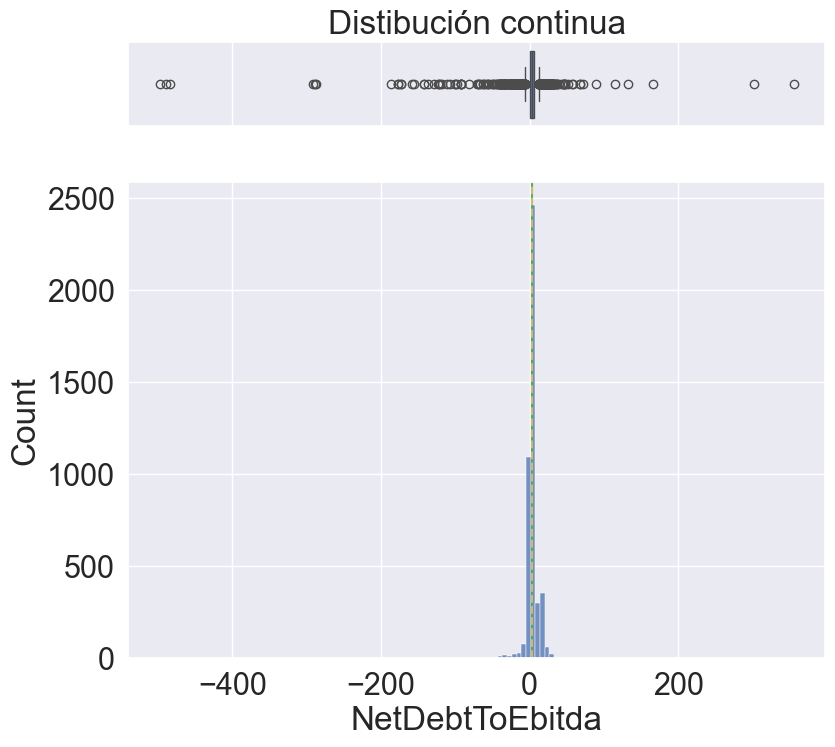

In [20]:
# Graficar
columna_a_graficar = 'NetDebtToEbitda' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [21]:
# Transformaciones logarítmicas

columnas_a_transformar = [ 
    'CurrentRatio',
    'RelativeAssets',
    'RelativeRevenue'
    ]
for columna in columnas_a_transformar:
    df_transformed[columna] = df_transformed[columna].fillna(0)
    df_transformed[f'{columna}_log'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

CapExToRevenue            38.570639
Dividends                 35.521576
MarketCap                 18.185563
Revenue_QoQ               18.148280
EnterpriseValue           17.250165
QuarterlyVariance         15.405736
NetIncome_TTM             14.198425
Open                      13.275513
Revenue_YoY               12.940255
PriceToBook               12.803792
CurrentDebt               12.171913
Close                     11.972299
OperatingCashFlow_TTM     11.488672
EBITDA_TTM                11.241055
OperatingIncome_TTM       11.233218
GrossProfit_TTM            9.169271
RelativeAssets_log         8.858181
FreeCashFlow_TTM           8.801180
DebtToEquity               7.805092
RelativeRevenue_log        7.332834
BasicAverageShares_TTM     7.170458
StockholdersEquity         7.046049
Ebitda_YoY                 6.337378
CurrentLiabilities         5.735895
TotalRevenue_TTM           5.650675
Ebitda_QoQ                 5.059815
CashAndCashEquivalents     4.991972
CurrentAssets              4

In [22]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = cols_monetarias + [
    # Variables de precio (posibles label)
    'Close',
    'Open',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    # Otras
    'Date', 
    'Ticker',
    'Dividends'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [23]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

OperatingMargins
ProfitMargins
ReturnOnEquity
ReturnOnAssets
DebtToEquity
Revenue_YoY
Revenue_QoQ
Ebitda_YoY
Ebitda_QoQ
Fcf_YoY
Fcf_QoQ
CapEx_YoY
CapEx_QoQ
NetDebtToEbitda
FcfToEbitda
CapExToRevenue
QuarterlyReturn
QuarterlyVariance
MarketCovariance
YearsSinceAdded
CurrentRatio_log
RelativeAssets_log
RelativeRevenue_log


In [24]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

RelativeAssets_log     1.782386
CapExToRevenue         1.712963
RelativeRevenue_log    1.660852
QuarterlyVariance      1.589659
YearsSinceAdded        1.193961
CurrentRatio_log       0.989957
Revenue_QoQ            0.968429
Revenue_YoY            0.717249
ProfitMargins          0.685003
QuarterlyReturn        0.540943
Ebitda_QoQ             0.432521
NetDebtToEbitda        0.401868
FcfToEbitda            0.347284
Ebitda_YoY             0.343606
Fcf_YoY                0.286633
Fcf_QoQ                0.101580
MarketCovariance       0.090507
ReturnOnEquity         0.058504
DebtToEquity           0.037286
OperatingMargins      -0.171239
CapEx_YoY             -0.315208
ReturnOnAssets        -0.333904
CapEx_QoQ             -0.765282
dtype: float64

Cont


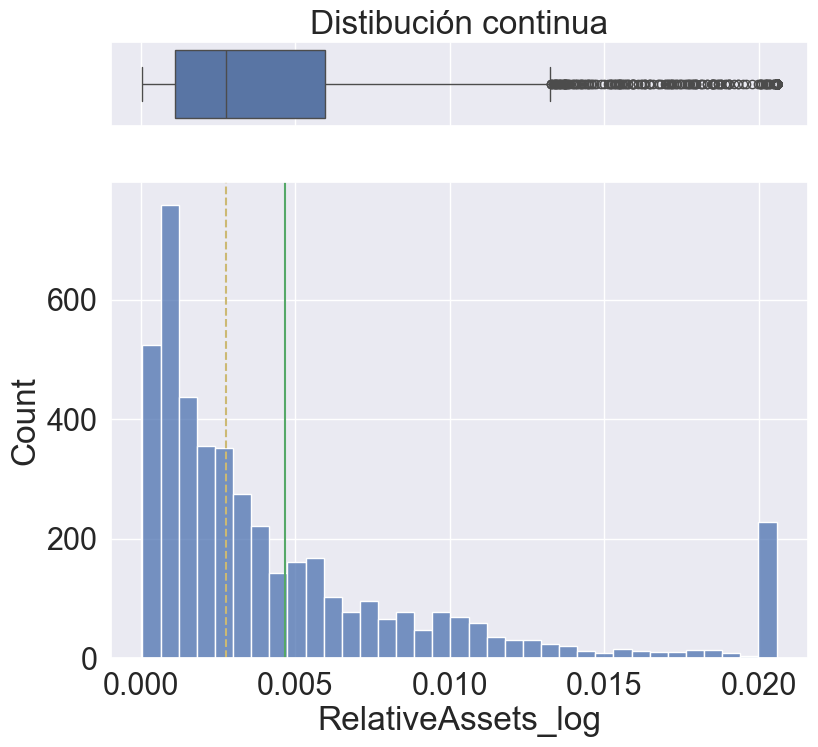

In [25]:
# Visualizar cambios
columna_a_graficar = 'RelativeAssets_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [26]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
OperatingMargins,4540.0,0.202717,0.165641,-0.430165,0.115623,0.194358,0.293251,0.827930
ProfitMargins,4540.0,0.124960,0.122461,-0.278288,0.062910,0.089786,0.176113,0.515916
ReturnOnEquity,4540.0,0.248825,0.559929,-1.028917,0.063778,0.160865,0.425019,1.509676
ReturnOnAssets,4540.0,0.076103,0.083560,-0.250971,0.033372,0.063636,0.126734,0.411282
DebtToEquity,4540.0,0.884617,1.507826,-2.702879,0.367954,0.718732,1.389133,4.487779
Revenue_YoY,4540.0,0.304473,0.251277,-0.931433,0.121321,0.446839,0.446839,1.471254
Revenue_QoQ,4540.0,0.081303,0.108093,-0.314578,0.031289,0.064009,0.145584,0.489162
Ebitda_YoY,4540.0,0.373619,0.355474,-0.951324,0.147310,0.510780,0.510780,1.640295
Ebitda_QoQ,4540.0,0.115728,0.205864,-0.504073,0.028856,0.101357,0.201287,0.731109
Fcf_YoY,4540.0,0.206038,0.295171,-0.335625,0.142559,0.182288,0.300353,0.774172


## Concatenación final de columnas

In [27]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  4540 non-null   float64       
 1   CurrentDebt             4540 non-null   float64       
 2   LongTermDebt            4540 non-null   float64       
 3   TotalDebt               4540 non-null   float64       
 4   StockholdersEquity      4540 non-null   float64       
 5   TotalAssets             4540 non-null   float64       
 6   CurrentAssets           4540 non-null   float64       
 7   CurrentLiabilities      4540 non-null   float64       
 8   OperatingCashFlow_TTM   4540 non-null   float64       
 9   InvestingCashFlow_TTM   4540 non-null   float64       
 10  FinancingCashFlow_TTM   4540 non-null   float64       
 11  FreeCashFlow_TTM        4540 non-null   float64       
 12  CapitalExpenditure_TTM  4540 non-null   float64 

In [28]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")